In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
import json
from pathlib import Path

all_deliveries = []

folder = Path("../data")

for file in folder.glob("*.json"):
    
    with open(file, 'r') as f:
        data = json.load(f)

    info = data["info"]

    match_id = file.stem

    toss_winner = info["toss"]["winner"]

    winner = info.get("outcome", {}).get("winner", "No Result")

    innings = data["innings"]

    for inning in innings:

        batting_team = inning["team"]

        for over in inning["overs"]:

            over_num = over["over"]

            for delivery in over["deliveries"]:

                batter = delivery["batter"]
                bowler = delivery["bowler"]

                runs = delivery["runs"]["batter"]

                wicket = 1 if "wickets" in delivery else 0

                all_deliveries.append({
                    "match_id": match_id,
                    "batting_team": batting_team,
                    "batter": batter,
                    "bowler": bowler,
                    "runs": runs,
                    "wicket": wicket,
                    "over": over_num,
                    "winner": winner,
                    "toss_winner": toss_winner
                })

df = pd.DataFrame(all_deliveries)

df.to_csv("../data/ipl_ball_by_ball.csv", index=False)

print("CSV Created Successfully")

CSV Created Successfully


In [12]:
df = pd.read_csv("../data/ipl_ball_by_ball.csv")

df.head()

,match_id,batting_team,batter,bowler,runs,wicket,over,winner,toss_winner
0,1082591,Sunrisers Hyderabad,DA Warner,TS Mills,0,0,0,Sunrisers Hyderabad,Royal Challengers Bangalore
1,1082591,Sunrisers Hyderabad,DA Warner,TS Mills,0,0,0,Sunrisers Hyderabad,Royal Challengers Bangalore
2,1082591,Sunrisers Hyderabad,DA Warner,TS Mills,4,0,0,Sunrisers Hyderabad,Royal Challengers Bangalore
3,1082591,Sunrisers Hyderabad,DA Warner,TS Mills,0,0,0,Sunrisers Hyderabad,Royal Challengers Bangalore
4,1082591,Sunrisers Hyderabad,DA Warner,TS Mills,0,0,0,Sunrisers Hyderabad,Royal Challengers Bangalore


In [13]:
matches = df[["match_id", "winner", "toss_winner"]].drop_duplicates()

matches["toss_match_win"] = matches["winner"] == matches["toss_winner"]

result = matches["toss_match_win"].value_counts(normalize=True) * 100

result

toss_match_win
True     50.605327
False    49.394673
Name: proportion, dtype: float64

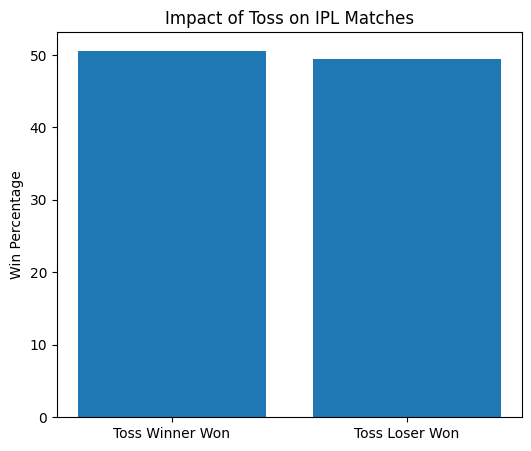

In [14]:
labels = ["Toss Winner Won", "Toss Loser Won"]

values = result.values

plt.figure(figsize=(6,5))

plt.bar(labels, values)

plt.ylabel("Win Percentage")

plt.title("Impact of Toss on IPL Matches")

plt.savefig("../charts/toss_analysis.png")

plt.show()

In [15]:
def phase(over):

    if over <= 5:
        return "Powerplay"

    elif over <= 15:
        return "Middle Overs"

    else:
        return "Death Overs"

df["phase"] = df["over"].apply(phase)

df.head()

,match_id,batting_team,batter,bowler,runs,wicket,over,winner,toss_winner,phase
0,1082591,Sunrisers Hyderabad,DA Warner,TS Mills,0,0,0,Sunrisers Hyderabad,Royal Challengers Bangalore,Powerplay
1,1082591,Sunrisers Hyderabad,DA Warner,TS Mills,0,0,0,Sunrisers Hyderabad,Royal Challengers Bangalore,Powerplay
2,1082591,Sunrisers Hyderabad,DA Warner,TS Mills,4,0,0,Sunrisers Hyderabad,Royal Challengers Bangalore,Powerplay
3,1082591,Sunrisers Hyderabad,DA Warner,TS Mills,0,0,0,Sunrisers Hyderabad,Royal Challengers Bangalore,Powerplay
4,1082591,Sunrisers Hyderabad,DA Warner,TS Mills,0,0,0,Sunrisers Hyderabad,Royal Challengers Bangalore,Powerplay


In [16]:
df["won_match"] = df["batting_team"] == df["winner"]

phase_runs = (
    df.groupby(["phase", "won_match"])["runs"]
    .mean()
    .reset_index()
)

phase_runs

,phase,won_match,runs
0,Death Overs,False,1.397346
1,Death Overs,True,1.719820
2,Middle Overs,False,1.165538
3,Middle Overs,True,1.325365
4,Powerplay,False,1.147774
5,Powerplay,True,1.295932


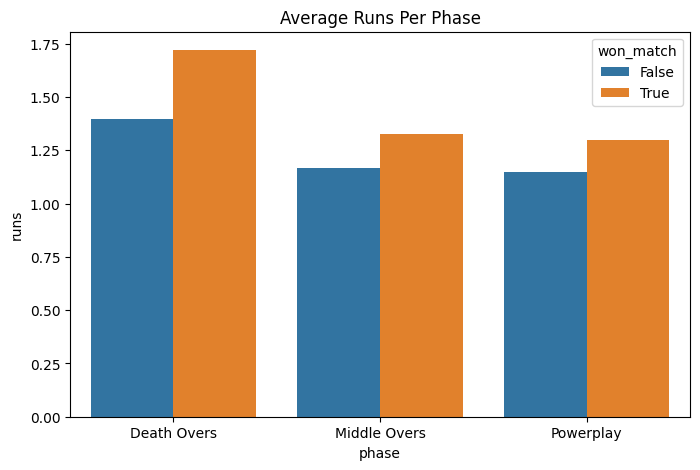

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=phase_runs,
    x="phase",
    y="runs",
    hue="won_match"
)

plt.title("Average Runs Per Phase")

plt.savefig("../charts/phase_analysis.png")

plt.show()

In [18]:
top_batters = (
    df.groupby("batter")["runs"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_batters

batter
V Kohli      9228
RG Sharma    7331
S Dhawan     6769
DA Warner    6567
KL Rahul     5828
Name: runs, dtype: int64

In [19]:
top_bowlers = (
    df.groupby("bowler")["wicket"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_bowlers

bowler
YS Chahal    242
B Kumar      239
SP Narine    229
JJ Bumrah    208
DJ Bravo     207
Name: wicket, dtype: int64